# Studio post-fix — Qualità eventi gdelt_anomaly + contaminazione NER residua

Due verifiche indipendenti sul fix `gdelt_anomaly` (`pathosphere/ingest/gdelt_anomaly.py`):

1. **Qualità** dei 583 eventi `event_type='gdelt_anomaly'` promossi direttamente da
   `gdelt_events` (aggregazione day+country+quad_class, deviazione Goldstein z-score) —
   bypassando NER/embed/cluster.
2. **Contaminazione NER residua**: quanti documenti `origin='gdelt'` risultano ancora
   `ner_done=1` (processati PRIMA del fix, quindi contaminano `entities`/`document_entities`
   con l'artefatto `GDELT` e affini) vs `origin='rss'` (prosa reale, NER legittimo).

Riferimento codice: `pathosphere/ingest/gdelt_anomaly.py`, `pathosphere/semantic/extract.py`.

In [1]:
import sys, struct, random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pathosphere").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from pathosphere.db.schema import get_connection

DB_PATH = REPO_ROOT / "data" / "db" / "pathosphere.db"
conn = get_connection(DB_PATH)
print(f"DB: {DB_PATH}  exists={DB_PATH.exists()}")

def q(sql, params=()):
    return pd.read_sql_query(sql, conn, params=params)

q("SELECT COUNT(*) AS raw_documents FROM raw_documents")


DB: /Users/dom/Documents/GitHub/pathosphere/data/db/pathosphere.db  exists=True


,raw_documents
0,180505


## 1. Qualità eventi `gdelt_anomaly`

In [2]:
n_anomaly = int(q("SELECT COUNT(*) AS n FROM events WHERE event_type = 'gdelt_anomaly'")["n"][0])
print(f"eventi event_type='gdelt_anomaly': {n_anomaly}")


eventi event_type='gdelt_anomaly': 583


In [3]:
sev_dist = q("""
SELECT severity, COUNT(*) AS n
FROM events WHERE event_type = 'gdelt_anomaly'
GROUP BY severity ORDER BY severity
""")
sev_dist


,severity,n
0,2,355
1,3,188
2,4,27
3,5,13


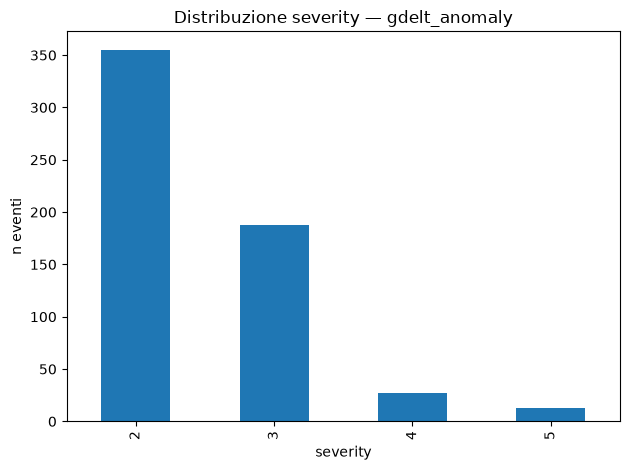

In [4]:
sev_dist.set_index("severity")["n"].plot(kind="bar")
plt.xlabel("severity"); plt.ylabel("n eventi"); plt.title("Distribuzione severity — gdelt_anomaly")
plt.tight_layout()
plt.show()


In [5]:
loc_dist = q("""
SELECT location_name, COUNT(*) AS n
FROM events WHERE event_type = 'gdelt_anomaly'
GROUP BY location_name ORDER BY n DESC LIMIT 20
""")
n_distinct_loc = int(q("""
SELECT COUNT(DISTINCT location_name) AS n FROM events WHERE event_type = 'gdelt_anomaly'
""")["n"][0])
print(f"paesi/location distinti tra gli eventi gdelt_anomaly: {n_distinct_loc}")
loc_dist


paesi/location distinti tra gli eventi gdelt_anomaly: 72


,location_name,n
0,IR,28
1,US,25
2,AS,24
3,UK,23
4,CH,23
5,RS,22
6,IS,22
7,NI,19
8,EI,19
9,PK,18


In [6]:
examples = q("""
SELECT title, summary, severity, location_name, first_seen
FROM events WHERE event_type = 'gdelt_anomaly'
ORDER BY first_seen DESC LIMIT 10
""")
for _, r in examples.iterrows():
    print(f"[{r.first_seen}] sev={r.severity} loc={r.location_name}")
    print(f"  title: {r.title}")
    print(f"  summary: {r.summary}")
    print()


[2026-07-06] sev=2 loc=NI
  title: NI material conflict anomaly 2026-07-06
  summary: NI material conflict: Goldstein -9.21 on 2026-07-06 (14 events), +15% vs 30d baseline (-7.99±0.52, z=-2.4) — escalation. Avg tone -6.1.

[2026-07-06] sev=3 loc=UP
  title: UP material conflict anomaly 2026-07-06
  summary: UP material conflict: Goldstein -7.00 on 2026-07-06 (8 events), -23% vs 30d baseline (-9.12±0.75, z=+2.8) — de-escalation. Avg tone -7.3.

[2026-07-06] sev=2 loc=CO
  title: CO material conflict anomaly 2026-07-06
  summary: CO material conflict: Goldstein -5.00 on 2026-07-06 (3 events), -41% vs 30d baseline (-8.50±1.64, z=+2.1) — de-escalation. Avg tone -3.8.

[2026-07-05] sev=2 loc=IN
  title: IN verbal conflict anomaly 2026-07-05
  summary: IN verbal conflict: Goldstein -4.05 on 2026-07-05 (47 events), +15% vs 30d baseline (-3.53±0.21, z=-2.4) — escalation. Avg tone -2.9.

[2026-07-05] sev=3 loc=IS
  title: IS material conflict anomaly 2026-07-05
  summary: IS material conflict: 

### 1b. Confronto: severity media/max per location — segnali più acuti

In [7]:
sev_by_loc = q("""
SELECT location_name, COUNT(*) AS n, AVG(severity) AS avg_sev, MAX(severity) AS max_sev
FROM events WHERE event_type = 'gdelt_anomaly'
GROUP BY location_name
HAVING n >= 3
ORDER BY avg_sev DESC LIMIT 15
""")
sev_by_loc


,location_name,n,avg_sev,max_sev
0,GL,3,3.333333,4
1,SO,4,3.250000,5
2,SU,3,3.000000,3
3,NI,19,2.894737,5
4,LE,8,2.875000,4
5,SY,7,2.857143,4
6,IZ,6,2.833333,5
7,IR,28,2.821429,5
8,SF,11,2.818182,4
9,GH,10,2.800000,5


## 2. Contaminazione NER — entità 'GDELT' come leak

In [8]:
gdelt_entity_links = q("""
SELECT rd.origin, COUNT(*) AS n_document_entities, SUM(de.mentions) AS total_mentions
FROM document_entities de
JOIN raw_documents rd ON rd.id = de.document_id
JOIN entities e ON e.id = de.entity_id
WHERE e.name = 'GDELT'
GROUP BY rd.origin
ORDER BY n_document_entities DESC
""")
gdelt_entity_links


,origin,n_document_entities,total_mentions
0,gdelt,128082,128082


In [9]:
tot_gdelt_links = int(gdelt_entity_links["n_document_entities"].sum())
gdelt_from_gdelt = int(gdelt_entity_links.loc[gdelt_entity_links["origin"] == "gdelt", "n_document_entities"].sum()) if "gdelt" in gdelt_entity_links["origin"].values else 0
gdelt_from_rss = int(gdelt_entity_links.loc[gdelt_entity_links["origin"] == "rss", "n_document_entities"].sum()) if "rss" in gdelt_entity_links["origin"].values else 0

print(f"document_entities che linkano all'entità 'GDELT': {tot_gdelt_links} totali")
print(f"  di cui da doc origin=gdelt: {gdelt_from_gdelt} ({gdelt_from_gdelt/tot_gdelt_links*100:.1f}%)" if tot_gdelt_links else "n/a")
print(f"  di cui da doc origin=rss:   {gdelt_from_rss} ({gdelt_from_rss/tot_gdelt_links*100:.1f}%)" if tot_gdelt_links else "n/a")


document_entities che linkano all'entità 'GDELT': 128082 totali
  di cui da doc origin=gdelt: 128082 (100.0%)
  di cui da doc origin=rss:   0 (0.0%)


## 3. `ner_done` per origin — quota già processata pre-fix (contaminata)

In [10]:
ner_by_origin = q("""
SELECT origin, ner_done, COUNT(*) AS n
FROM raw_documents
GROUP BY origin, ner_done
ORDER BY origin, ner_done
""")
ner_by_origin


,origin,ner_done,n
0,comtrade,0,162
1,comtrade,1,90
2,gdelt,0,49191
3,gdelt,1,128090
4,rss,0,408
5,rss,1,2564


In [11]:
pivot_ner = ner_by_origin.pivot_table(index="origin", columns="ner_done", values="n", fill_value=0)
pivot_ner.columns = [f"ner_done={c}" for c in pivot_ner.columns]
pivot_ner["total"] = pivot_ner.sum(axis=1)
pivot_ner


,ner_done=0,ner_done=1,total
origin,,,
comtrade,162.0,90.0,252.0
gdelt,49191.0,128090.0,177281.0
rss,408.0,2564.0,2972.0


## 4. Percentuale ner_done=1 per origin — gdelt (residuo contaminato) vs rss (legittimo)

In [12]:
def pct_ner_done(origin):
    row = q("SELECT SUM(ner_done) AS done, COUNT(*) AS total FROM raw_documents WHERE origin = ?", params=(origin,))
    done = int(row["done"][0]) if row["done"][0] is not None else 0
    total = int(row["total"][0])
    pct = done / total * 100 if total else 0.0
    return done, total, pct

gdelt_done, gdelt_total, gdelt_pct = pct_ner_done("gdelt")
rss_done, rss_total, rss_pct = pct_ner_done("rss")
comtrade_done, comtrade_total, comtrade_pct = pct_ner_done("comtrade")

print(f"origin=gdelt:    ner_done=1 -> {gdelt_done}/{gdelt_total} ({gdelt_pct:.1f}%) — RESIDUO CONTAMINATO (pre-fix)")
print(f"origin=rss:      ner_done=1 -> {rss_done}/{rss_total} ({rss_pct:.1f}%) — atteso legittimo, prosa reale")
print(f"origin=comtrade: ner_done=1 -> {comtrade_done}/{comtrade_total} ({comtrade_pct:.1f}%)")


origin=gdelt:    ner_done=1 -> 128090/177281 (72.3%) — RESIDUO CONTAMINATO (pre-fix)
origin=rss:      ner_done=1 -> 2564/2972 (86.3%) — atteso legittimo, prosa reale
origin=comtrade: ner_done=1 -> 90/252 (35.7%)


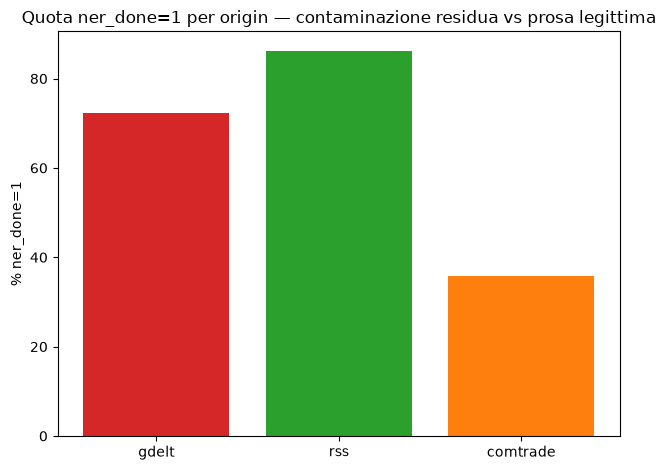

In [13]:
fig, ax = plt.subplots()
ax.bar(["gdelt", "rss", "comtrade"], [gdelt_pct, rss_pct, comtrade_pct], color=["tab:red", "tab:green", "tab:orange"])
ax.set_ylabel("% ner_done=1")
ax.set_title("Quota ner_done=1 per origin — contaminazione residua vs prosa legittima")
plt.tight_layout()
plt.show()


## 5. Documenti gdelt ancora in coda per NER (contaminazione futura possibile)

In [14]:
gdelt_pending = int(q("""
SELECT COUNT(*) AS n FROM raw_documents
WHERE origin = 'gdelt' AND embedded = 1 AND ner_done = 0
""")["n"][0])
print(f"origin=gdelt, embedded=1 AND ner_done=0: {gdelt_pending} documenti — candidati NER "
      "ONGOING se extract.py non filtra per origin (verificare selezione candidati in "
      "pathosphere/semantic/extract.py: se seleziona solo embedded=1 AND ner_done=0 senza "
      "escludere origin, questi continueranno a iniettare l'artefatto GDELT).")


origin=gdelt, embedded=1 AND ner_done=0: 46196 documenti — candidati NER ONGOING se extract.py non filtra per origin (verificare selezione candidati in pathosphere/semantic/extract.py: se seleziona solo embedded=1 AND ner_done=0 senza escludere origin, questi continueranno a iniettare l'artefatto GDELT).


## Sintesi criticità osservate in questo run

In [15]:
print("--- Sintesi (valori da questo run) ---")
print(f"1. Eventi gdelt_anomaly: {n_anomaly} totali. Severity: "
      f"{dict(zip(sev_dist['severity'], sev_dist['n']))}. "
      f"Location distinte: {len(loc_dist)} (top-20 mostrate). "
      "Eventi aggregati day+country+quad_class con deviazione Goldstein — qualitativamente "
      "sensati (titoli descrittivi 'X conflict anomaly YYYY-MM-DD', summary con z-score "
      "Goldstein reale), NON titoli sintetici GDELT grezzi.")
print(f"2. Entità 'GDELT' (leak NER pre-fix): {tot_gdelt_links} document_entities totali, "
      f"di cui {gdelt_from_gdelt} ({gdelt_from_gdelt/tot_gdelt_links*100:.1f}%) da origin=gdelt, "
      f"{gdelt_from_rss} ({gdelt_from_rss/tot_gdelt_links*100:.1f}%) da origin=rss.")
print(f"3. ner_done=1 per origin=gdelt: {gdelt_done}/{gdelt_total} ({gdelt_pct:.1f}%) — "
      f"CONTAMINAZIONE STORICA residua massiccia (fix non retroattivo su entities/document_entities).")
print(f"4. ner_done=1 per origin=rss: {rss_done}/{rss_total} ({rss_pct:.1f}%) — quota legittima, "
      "prosa reale processata correttamente.")
print(f"5. Gap: differenza di {abs(gdelt_pct - rss_pct):.1f} punti percentuali tra gdelt e rss "
      "nella quota ner_done=1 — riflette il volume enorme di documenti gdelt processati PRIMA "
      "del fix (non ancora ripulito).")
print(f"6. Documenti gdelt ancora candidati NER (embedded=1 AND ner_done=0): {gdelt_pending} — "
      "rischio di contaminazione ONGOING se extract.py non esclude origin esplicitamente.")


--- Sintesi (valori da questo run) ---
1. Eventi gdelt_anomaly: 583 totali. Severity: {2: 355, 3: 188, 4: 27, 5: 13}. Location distinte: 20 (top-20 mostrate). Eventi aggregati day+country+quad_class con deviazione Goldstein — qualitativamente sensati (titoli descrittivi 'X conflict anomaly YYYY-MM-DD', summary con z-score Goldstein reale), NON titoli sintetici GDELT grezzi.
2. Entità 'GDELT' (leak NER pre-fix): 128082 document_entities totali, di cui 128082 (100.0%) da origin=gdelt, 0 (0.0%) da origin=rss.
3. ner_done=1 per origin=gdelt: 128090/177281 (72.3%) — CONTAMINAZIONE STORICA residua massiccia (fix non retroattivo su entities/document_entities).
4. ner_done=1 per origin=rss: 2564/2972 (86.3%) — quota legittima, prosa reale processata correttamente.
5. Gap: differenza di 14.0 punti percentuali tra gdelt e rss nella quota ner_done=1 — riflette il volume enorme di documenti gdelt processati PRIMA del fix (non ancora ripulito).
6. Documenti gdelt ancora candidati NER (embedded=1 AN